In [1]:
import numpy as np
import random
from numpy.linalg import solve, norm
from dataclasses import dataclass
from typing import Callable, Optional, Dict, Any, Union
import matplotlib.pyplot as plt

In [2]:

def sigmoid(x: np.ndarray) -> np.ndarray:
    # numerically safer sigmoid
    x = np.clip(x, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-x))


def augment_X(X: np.ndarray) -> np.ndarray:
    """
    Append a column of ones for affine models.
    X: (n, d)
    returns: (n, d+1)
    """
    n = X.shape[0]
    return np.hstack([X, np.ones((n, 1))])


def sample_uniform_simplex(vertices: np.ndarray, n_samples: int, rng=None) -> np.ndarray:
    """
    Uniformly sample points from a d-simplex in R^d given by d+1 vertices.

    vertices: shape (d+1, d)
    returns: shape (n_samples, d)
    """
    if rng is None:
        rng = np.random.default_rng()

    m, d = vertices.shape
    if m != d + 1:
        raise ValueError(
            f"For simplex sampling, expected vertices.shape = (d+1, d), got {vertices.shape}."
        )

    # Dirichlet(1,...,1) gives uniform barycentric coordinates
    bary = rng.dirichlet(alpha=np.ones(m), size=n_samples)  # (n_samples, d+1)
    return bary @ vertices




In [206]:
def evaluate_error(
    f_true,
    f_pred,
    bounds: np.ndarray,
    n_samples: int,
    random_state: int = 0,
    rel_floor: float = 1e-12,
):
    """
    Compare two scalar-valued functions on random points sampled uniformly
    from a hypercube / hyper-rectangle.

    Parameters
    ----------
    f_true : callable
        Ground-truth function, takes x and returns scalar.
    f_pred : callable
        Surrogate/prediction function, takes x and returns scalar.
    bounds : np.ndarray
        Array of shape (d, 2), where bounds[i] = [low_i, high_i].
    n_samples : int
        Number of random evaluation points.
    random_state : int
        RNG seed.
    rel_floor : float
        Stabilizer for pointwise relative error near zero.

    Returns
    -------
    dict with aggregate error metrics and sampled values.
    """
    bounds = np.asarray(bounds, dtype=float)
    if bounds.ndim != 2 or bounds.shape[1] != 2:
        raise ValueError(f"bounds must have shape (d, 2), got {bounds.shape}")

    lows = bounds[:, 0]
    highs = bounds[:, 1]
    if np.any(lows >= highs):
        raise ValueError("Each bound must satisfy low < high.")

    rng = np.random.default_rng(random_state)
    X = rng.uniform(lows, highs, size=(n_samples, bounds.shape[0]))
    print("Data shape:", X.shape)

    y_true = np.array([f_true(x) for x in X], dtype=float)
    y_pred = np.array([f_pred(x) for x in X], dtype=float)

    abs_err = np.abs(y_true - y_pred)
    sq_err = (y_true - y_pred) ** 2
    pointwise_rel_err = abs_err / np.maximum(np.abs(y_true), rel_floor)

    rel_l2 = np.linalg.norm(y_true - y_pred) / max(np.linalg.norm(y_true), rel_floor)
    rmse = float(np.sqrt(np.mean(sq_err)))
    mae = float(np.mean(abs_err))
    median_rel = float(np.median(pointwise_rel_err))
    max_rel = float(np.max(pointwise_rel_err))

    return {
        "relative_l2_error": float(rel_l2),
        "median_pointwise_relative_error": median_rel,
        "max_pointwise_relative_error": max_rel,
        "abs_err": abs_err,
        "pointwise_relative_error": pointwise_rel_err,
        "L2 norm": float(np.linalg.norm(y_true / np.sqrt(len(y_true)))),
    }


## Tree Setup

In [124]:
@dataclass
class PolytopeRegion:
    """
    Polyhedral region represented as A x <= b.
    """
    A: np.ndarray
    b: np.ndarray
    depth: int = 0
    tag: Optional[str] = None


@dataclass
class AffineLeaf:
    beta: np.ndarray
    parent: Optional[Any] = None
    region: Optional[PolytopeRegion] = None
    depth: int = 0
    node_id: Optional[str] = None

    def predict_one(self, x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        x_aug = np.append(x, 1.0)
        return float(x_aug @ self.beta)


@dataclass
class SplitNode:
    w: np.ndarray
    z: float
    left: Any
    right: Any
    parent: Optional[Any] = None
    region: Optional[PolytopeRegion] = None
    depth: int = 0
    node_id: Optional[str] = None
    fit_result: Optional[Any] = None

    def route(self, x: np.ndarray):
        x = np.asarray(x, dtype=float)
        if float(self.w @ x - self.z) >= 0.0:
            return self.right
        return self.left


TreeNode = Union[AffineLeaf, SplitNode]


class PiecewiseLinearTree:
    def __init__(self, root: Optional[TreeNode] = None):
        self.root = root

    def predict_one(self, x: np.ndarray) -> float:
        if self.root is None:
            raise ValueError("Tree has no root node.")

        node = self.root
        while isinstance(node, SplitNode):
            node = node.route(x)

        return node.predict_one(x)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        return np.array([self.predict_one(x) for x in X], dtype=float)

    def leaf_for_point(self, x: np.ndarray) -> AffineLeaf:
        if self.root is None:
            raise ValueError("Tree has no root node.")

        node = self.root
        while isinstance(node, SplitNode):
            node = node.route(x)

        return node
    
    def num_leaves(self) -> int:
        def _count(node) -> int:
            if isinstance(node, AffineLeaf):
                return 1
            return _count(node.left) + _count(node.right)

        if self.root is None:
            return 
        return _count(self.root)


    def max_depth(self) -> int:
        def _depth(node):
            if isinstance(node, AffineLeaf):
                return 0
            return 1 + max(_depth(node.left), _depth(node.right))

        if self.root is None:
            return 0
        return _depth(self.root)
    
    def t_range(self):
        vals = []

        def _walk(node):
            if node is None:
                return
            t = getattr(node, "t_cell", None)
            if t is not None:
                vals.append(float(t))
            if isinstance(node, SplitNode):
                _walk(node.left)
                _walk(node.right)

        _walk(self.root)

        if not vals:
            return None
        return min(vals), max(vals)

    def get_node(self, node_id) -> TreeNode:
        if self.root is None:
            raise ValueError("Tree has no root node.")

        if node_id in ("root", "", None):
            return self.root

        parts = node_id.split("/")
        if parts[0] != "root":
            raise ValueError(f"node_id must start with 'root', got {node_id!r}")

        node = self.root
        for step in parts[1:]:
            if isinstance(node, AffineLeaf):
                raise ValueError(f"Path {node_id!r} goes past a leaf at {node.node_id!r}")
            if step == "L":
                node = node.left
            elif step == "R":
                node = node.right
            else:
                raise ValueError(f"Invalid step {step!r} in {node_id!r}")

        return node


In [54]:
@dataclass
class FitResult:
    w: np.ndarray
    z: float
    beta0: np.ndarray
    beta1: np.ndarray
    loss_history: list
    grad_norm_history: list
    n_iters: int
    converged: bool
    w_norm_penalty: float
    X: np.ndarray
    y: np.ndarray
    pi: np.ndarray


class biLinear_fit:
    """
    Soft hyperplane-gated two-affine-model fit:
        pi_i = sigmoid((w^T x_i - z)/t)

    Objective:
        sum_i (1-pi_i) (y_i - <beta0, x~_i>)^2
      + sum_i pi_i     (y_i - <beta1, x~_i>)^2

    where x~_i = [x_i; 1].
    """

    def __init__(
        self,
        oracle: Optional[Callable[[np.ndarray], float]] = None,
        vertices: Optional[np.ndarray] = None,
        t: float = 1.0,
        n_samples: int = 500,
        ridge: float = 1e-8,
        w_norm_penalty: float = 0.5,
        random_state: Optional[int] = None,
        X: Optional[np.ndarray] = None,
        y: Optional[np.ndarray] = None,
    ):

        """
        oracle: function f: R^d -> R
        vertices: simplex vertices, shape (d+1, d)
        t: fixed sigmoid sharpness parameter
        n_samples: number of queried points
        ridge: ridge regularization for weighted LS
        """
        self.oracle = oracle
        self.vertices = None if vertices is None else np.asarray(vertices, dtype=float)
        self.t = float(t)
        self.n_samples = int(n_samples)
        self.ridge = float(ridge)
        self.w_norm_penalty = float(w_norm_penalty)
        self.rng = np.random.default_rng(random_state)

        self.X = None
        self.y = None

        if X is not None or y is not None:
            if X is None or y is None:
                raise ValueError("If providing data directly, both X and y must be given.")

            X = np.asarray(X, dtype=float)
            y = np.asarray(y, dtype=float).reshape(-1)

            if X.ndim != 2:
                raise ValueError(f"X must have shape (n, d), got {X.shape}.")
            if y.ndim != 1:
                raise ValueError(f"y must have shape (n,), got {y.shape}.")
            if X.shape[0] != y.shape[0]:
                raise ValueError(
                    f"X and y must have the same number of samples, got {X.shape[0]} and {y.shape[0]}."
                )

            self.X = X.copy()
            self.y = y.copy()
            self.d = X.shape[1]
            self.data_provided = True

        else:
            if oracle is None:
                raise ValueError("oracle must be provided when X, y are not given.")
            if self.vertices is None:
                raise ValueError("vertices must be provided when X, y are not given.")

            m, d = self.vertices.shape
            if m != d + 1:
                raise ValueError(
                    "Current implementation assumes domain is a simplex with shape (d+1, d)."
                )

            self.d = d
            self.data_provided = False

        self.w = None
        self.z = None
        self.beta0 = None
        self.beta1 = None

        self.loss_history = []
        self.grad_norm_history = []

    # ----------------------------
    # Sampling / data generation
    # ----------------------------
    def sample_domain(self) -> np.ndarray:
        return sample_uniform_simplex(self.vertices, self.n_samples, rng=self.rng)

    def query_oracle(self, X: np.ndarray) -> np.ndarray:
        y = np.array([self.oracle(x) for x in X], dtype=float)
        return y

    def generate_data(self):
        if self.data_provided:
            return
        self.X = self.sample_domain()
        self.y = self.query_oracle(self.X)
    # ----------------------------
    # Initialization
    # ----------------------------
    def initialize_params(self, beta_sep: float = 1e-3):
        """
        Simple initialization:
        - random unit w
        - z = median(w^T x)
        - beta0, beta1 initialized as small perturbations of a global affine fit

        This avoids the degenerate beta0 == beta1 case without doing
        additional split-dependent least-squares solves.
        """
        w = self.rng.normal(size=self.d)
        w /= max(norm(w), 1e-12)

        proj = self.X @ w
        z = float(np.median(proj))

        X_aug = augment_X(self.X)
        A = X_aug.T @ X_aug + self.ridge * np.eye(self.d + 1)
        b = X_aug.T @ self.y
        beta_global = solve(A, b)

        delta = self.rng.normal(size=self.d + 1)
        delta /= max(norm(delta), 1e-12)
        delta *= beta_sep * max(1.0, norm(beta_global))

        self.w = w
        self.z = z
        self.beta0 = beta_global - delta
        self.beta1 = beta_global + delta

    # ----------------------------
    # Core model pieces
    # ----------------------------
    def compute_pi(self, w: np.ndarray, z: float) -> np.ndarray:
        s = (self.X @ w - z) / self.t
        return sigmoid(s)

    def solve_weighted_ls(self, pi: np.ndarray):
        """
        Solve for beta0, beta1 exactly, given fixed pi.
        """
        X_aug = augment_X(self.X)
        I = np.eye(self.d + 1)

        w0 = 1.0 - pi
        w1 = pi

        # Weighted normal equations
        # X^T W X = X^T (diag(w)) X = (X * w[:,None])^T X
        A0 = X_aug.T @ (X_aug * w0[:, None]) + self.ridge * I
        b0 = X_aug.T @ (self.y * w0)

        A1 = X_aug.T @ (X_aug * w1[:, None]) + self.ridge * I
        b1 = X_aug.T @ (self.y * w1)

        beta0 = solve(A0, b0)
        beta1 = solve(A1, b1)

        return beta0, beta1

    def objective(self, w: np.ndarray, z: float, beta0: np.ndarray, beta1: np.ndarray) -> float:
        pi = self.compute_pi(w, z)
        X_aug = augment_X(self.X)

        r0 = self.y - X_aug @ beta0
        r1 = self.y - X_aug @ beta1

        val = np.sum((1.0 - pi) * (r0 ** 2) + pi * (r1 ** 2))
        wpenalty = 0.5 * self.w_norm_penalty * ((np.dot(w, w) - 1.0) ** 2)
        return 0.5 * float(val) + wpenalty

    def reduced_objective(self, w: np.ndarray, z: float):
        """
        E(w,z) = min_{beta0,beta1} J(beta0,beta1,w,z)
        """
        pi = self.compute_pi(w, z)
        beta0, beta1 = self.solve_weighted_ls(pi)
        val = self.objective(w, z, beta0, beta1)
        return val, pi, beta0, beta1

    def gradient_wz_given_betas(
        self, w: np.ndarray, z: float, beta0: np.ndarray, beta1: np.ndarray
    ):
        """
        Gradient wrt (w,z), holding beta0,beta1 fixed.

        J = 1/2 sum_i [ (1-pi_i) r0_i^2 + pi_i r1_i^2 ]

        dJ/dpi_i = 1/2 (r1_i^2 - r0_i^2)
        dpi_i/ds_i = pi_i(1-pi_i)
        s_i = (w^T x_i - z)/t
        """
        pi = self.compute_pi(w, z)
        X_aug = augment_X(self.X)

        r0 = self.y - X_aug @ beta0
        r1 = self.y - X_aug @ beta1

        coeff = 0.5 * (r1**2 - r0**2) * pi * (1.0 - pi)  # shape (n,)

        grad_w = (self.X.T @ coeff) / self.t
        grad_w += 2 * self.w_norm_penalty * (np.dot(w, w) - 1.0) * w
        grad_z = -np.sum(coeff) / self.t

        return grad_w, float(grad_z)

    # ----------------------------
    # Backtracking GD on (w, z)
    # ----------------------------
    def backtracking_step(
        self,
        w: np.ndarray,
        z: float,
        beta0: np.ndarray,
        beta1: np.ndarray,
        grad_w: np.ndarray,
        grad_z: float,
        alpha0: float = 1.0,
        rho: float = 0.5, #0.5
        c: float = 1e-4,
        max_backtracks: int = 25, #25
    ):
        """
        Backtracking line search on reduced objective.
        After proposing (w_new,z_new), we re-solve weighted LS.
        """
        curr_val = self.objective(w, z, beta0, beta1)

        grad_vec = np.concatenate([grad_w, np.array([grad_z])])
        grad_sq = np.dot(grad_vec, grad_vec)

        alpha = alpha0
        for _ in range(max_backtracks):
            w_new = w - alpha * grad_w
            w_norm = norm(w_new)
            if w_norm < 1e-12:
                alpha *= rho
                continue
            
            # w_new = w_new / w_norm
            z_new = z - alpha * grad_z
            # z_new = z_new / w_norm

            new_val = self.objective(w_new, z_new, beta0, beta1)

            # Armijo condition on frozen-beta objective
            if new_val <= curr_val - c * alpha * grad_sq:
                # print("succesful stepsize:", alpha)
                pi_new = self.compute_pi(w_new, z_new)
                return w_new, z_new, pi_new, beta0, beta1, new_val, alpha

            alpha *= rho

        # fallback: no successful step
        pi_curr = self.compute_pi(w, z)
        return w, z, pi_curr, beta0, beta1, curr_val, 0.0

    # ----------------------------
    # Main fit loop
    # ----------------------------
    def fit(
        self,
        max_iters: int = 100,
        tol: float = 1e-6,
        alpha0: float = 1.0,
        verbose: bool = True,
        regenerate_data: bool = True,
    ) -> FitResult:

        if self.data_provided:
            regenerate_data = False

        if regenerate_data or self.X is None or self.y is None:
            self.generate_data()

        self.initialize_params()

        converged = False

        for k in range(max_iters):
            # exact beta update for current (w,z)
            pi = self.compute_pi(self.w, self.z)
            self.beta0, self.beta1 = self.solve_weighted_ls(pi)

            # evaluate reduced objective
            curr_loss = self.objective(self.w, self.z, self.beta0, self.beta1)

            # gradient wrt (w,z), holding betas fixed
            grad_w, grad_z = self.gradient_wz_given_betas(
                self.w, self.z, self.beta0, self.beta1
            )
            grad_norm = np.sqrt(np.dot(grad_w, grad_w) + grad_z**2)

            self.loss_history.append(curr_loss)
            self.grad_norm_history.append(grad_norm)

            if verbose and (k % 10 == 0 or k == max_iters - 1):
                print(
                    f"iter={k:3d} | loss={curr_loss:.6e} | grad_norm={grad_norm:.6e}"
                )

            if grad_norm < tol:
                converged = True
                break

            # backtracking update on (w,z), betas are frozen here 
            self.w, self.z, pi, self.beta0, self.beta1, new_loss, step = self.backtracking_step(
                self.w,
                self.z,
                self.beta0,
                self.beta1,
                grad_w,
                grad_z,
                alpha0=alpha0,
            )

            # Control w, z sizes
            # w_norm = norm(self.w)
            # self.w = self.w / w_norm
            # self.z = self.z / w_norm

            # re-fit betas after accepting the (w,z) step
            pi = self.compute_pi(self.w, self.z)
            self.beta0, self.beta1 = self.solve_weighted_ls(pi)
            new_loss = self.objective(self.w, self.z, self.beta0, self.beta1)

            if step == 0.0:
                print("Backtracking failed to find a descent step.")
                break

            if abs(curr_loss - new_loss) < tol * max(1.0, abs(curr_loss)):
                converged = True
                self.loss_history.append(new_loss)
                self.grad_norm_history.append(grad_norm)
                break

        final_pi = self.compute_pi(self.w, self.z)

        return FitResult(
            w=self.w.copy(),
            z=float(self.z),
            beta0=self.beta0.copy(),
            beta1=self.beta1.copy(),
            loss_history=self.loss_history.copy(),
            grad_norm_history=self.grad_norm_history.copy(),
            n_iters=len(self.loss_history),
            converged=converged,
            w_norm_penalty=self.w_norm_penalty,
            X=self.X.copy(),
            y=self.y.copy(),
            pi=final_pi.copy(),
        )

    # ----------------------------
    # Prediction helpers
    # ----------------------------
    def predict_soft(self, X_new: np.ndarray) -> np.ndarray:
        X_new = np.asarray(X_new, dtype=float)
        X_aug = augment_X(X_new)
        pi = sigmoid((X_new @ self.w - self.z) / self.t)
        y0 = X_aug @ self.beta0
        y1 = X_aug @ self.beta1

        # soft blended prediction; useful for visualization only
        return (1.0 - pi) * y0 + pi * y1

    def predict_hard(self, X_new: np.ndarray) -> np.ndarray:
        X_new = np.asarray(X_new, dtype=float)
        X_aug = augment_X(X_new)
        side = (X_new @ self.w - self.z) >= 0.0
        y0 = X_aug @ self.beta0
        y1 = X_aug @ self.beta1
        return np.where(side, y1, y0)

iter=  0 | loss=2.589946e+00 | grad_norm=6.130419e+00
succesful stepsize: 0.0078125
succesful stepsize: 0.015625
succesful stepsize: 0.00390625
succesful stepsize: 0.25
succesful stepsize: 0.125
succesful stepsize: 0.03125
succesful stepsize: 0.125
succesful stepsize: 0.03125
succesful stepsize: 0.25
succesful stepsize: 0.03125
iter= 10 | loss=3.872395e-01 | grad_norm=1.082542e+00
succesful stepsize: 0.03125
succesful stepsize: 0.0625
succesful stepsize: 0.0625
succesful stepsize: 0.0625
succesful stepsize: 0.0625
succesful stepsize: 0.0625
succesful stepsize: 0.0625
succesful stepsize: 0.125
succesful stepsize: 0.0625
succesful stepsize: 0.125
iter= 20 | loss=3.598218e-01 | grad_norm=2.283547e-01
succesful stepsize: 0.125
succesful stepsize: 0.125
succesful stepsize: 0.125
succesful stepsize: 1.0
succesful stepsize: 0.0078125
succesful stepsize: 0.0625
succesful stepsize: 0.0078125
succesful stepsize: 0.5
succesful stepsize: 0.0078125
succesful stepsize: 0.015625
iter= 30 | loss=1.743

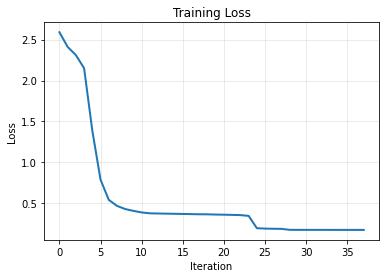

In [6]:
# 2D simplex (triangle)
vertices = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [0.2, 1.0],
])

true_w = np.array([1, -1])
true_z = 0.0


def oracle(x):
    # true split: x0 + x1 = 0.75
    if true_w[0]*x[0] + true_w[1]*x[1] < true_z:
        return 2.0 * x[0] - 1.0 * x[1] + 0.3
    else:
        return -1.5 * x[0] + 2.5 * x[1] - 0.2

model = biLinear_fit(
    oracle=oracle,
    vertices=vertices,
    t=0.02, #0.01
    n_samples=50, #250
    ridge=1e-8,
    random_state=3,
)

result = model.fit(max_iters=250, tol=1e-5, alpha0=1.0, verbose=True)

print("converged:", result.converged)
print("w =", result.w)
print("z =", result.z)
print("beta0 =", result.beta0)
print("beta1 =", result.beta1)

# Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(result.loss_history, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.show()


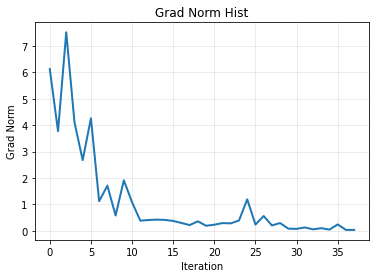

In [7]:
# Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(result.grad_norm_history, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Grad Norm")
plt.title("Grad Norm Hist")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
def plot_two_partition_lines(vertices, true_w, true_z, pred_w, pred_z, X=None):
    vertices = np.asarray(vertices, dtype=float)
    if vertices.shape != (3, 2):
        raise ValueError("This function expects a 2D simplex with shape (3, 2).")

    def clipped_line_in_triangle(w, z, verts, tol=1e-10):
        pts = []
        edges = [(0, 1), (1, 2), (2, 0)]

        for i, j in edges:
            a = verts[i]
            b = verts[j]
            d = b - a

            denom = np.dot(w, d)
            numer = z - np.dot(w, a)

            if abs(denom) < tol:
                continue

            t = numer / denom
            if -tol <= t <= 1 + tol:
                p = a + t * d
                pts.append(p)

        uniq = []
        for p in pts:
            if not any(np.linalg.norm(p - q) < 1e-8 for q in uniq):
                uniq.append(p)

        if len(uniq) >= 2:
            return np.array(uniq[:2])
        return None

    fig, ax = plt.subplots(figsize=(6, 6))

    # simplex
    closed = np.vstack([vertices, vertices[0]])
    ax.plot(closed[:, 0], closed[:, 1], color="black", lw=2, label="Simplex")

    # sampled points colored by true side
    if X is not None:
        X = np.asarray(X, dtype=float)
        true_side = (X @ true_w - true_z) >= 0.0

        ax.scatter(
            X[~true_side, 0], X[~true_side, 1],
            color="tab:blue", s=20, alpha=0.8, label="True side < 0"
        )
        ax.scatter(
            X[true_side, 0], X[true_side, 1],
            color="tab:orange", s=20, alpha=0.8, label="True side >= 0"
        )

    # lines
    true_seg = clipped_line_in_triangle(true_w, true_z, vertices)
    pred_seg = clipped_line_in_triangle(pred_w, pred_z, vertices)

    if true_seg is not None:
        ax.plot(true_seg[:, 0], true_seg[:, 1], color="blue", lw=2.5, label="True line")

    if pred_seg is not None:
        ax.plot(pred_seg[:, 0], pred_seg[:, 1], color="red", lw=2.5, ls="--", label="Predicted line")

    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("True vs Predicted Partition Line")
    ax.legend()
    plt.show()


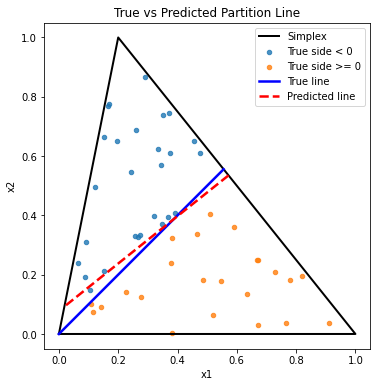

In [9]:
plot_two_partition_lines(
    vertices=model.vertices,
    true_w=true_w,
    true_z=true_z,
    pred_w=result.w,
    pred_z=result.z,
    X=result.X,
)


## Uniform Sampling Convex Polyhedra

In [10]:
def find_feasible_point(A, b, max_tries=20000, seed=0):
    rng = np.random.default_rng(seed)
    d = A.shape[1]
    for _ in range(max_tries):
        x = rng.uniform(-1.0, 1.0, size=d)
        if np.all(A @ x <= b):
            return x
    raise RuntimeError("Could not find a feasible starting point.")

# Mixing time scales as O(d^3) verify this
def hit_and_run_sample(A, b, n_samples, burn_in=1000, thinning=10, x0=None, seed=0):
    rng = np.random.default_rng(seed)
    m, d = A.shape

    if x0 is None:
        x = find_feasible_point(A, b, seed=seed)
    else:
        x = np.array(x0, dtype=float)
        if not np.all(A @ x <= b):
            raise ValueError("x0 is not feasible.")
    
    samples = []
    total_steps = burn_in + n_samples * thinning

    for step in range(total_steps):
        u = rng.normal(size=d)
        u /= np.linalg.norm(u)

        Au = A @ u
        Ax = A @ x

        t_low = -np.inf
        t_high = np.inf

        for i in range(m):
            if abs(Au[i]) < 1e-14:
                if Ax[i] > b[i]:
                    raise RuntimeError("Current point became infeasible.")
                continue

            t = (b[i] - Ax[i]) / Au[i]
            if Au[i] > 0:
                t_high = min(t_high, t)
            else:
                t_low = max(t_low, t)

        if t_low > t_high:
            raise RuntimeError("Empty step interval encountered.")

        t_new = rng.uniform(t_low, t_high)
        x = x + t_new * u

        if step >= burn_in and (step - burn_in) % thinning == 0:
            samples.append(x.copy())

    return np.array(samples)


(2000, 2)
True


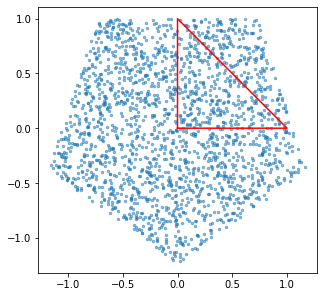

In [11]:
A = np.array([
    [ 0.0,  1.0],
    [ 0.95,  0.31],
    [ 0.59, -0.81],
    [-0.59, -0.81],
    [-0.95,  0.31],
])
b = np.ones(5)


pts = hit_and_run_sample(A, b, n_samples=2000, burn_in=1000, thinning=5, seed=1)

print(pts.shape)
print(np.all(A @ pts.T <= b[:, None] + 1e-10))

plt.figure(figsize=(5, 5))
plt.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.5)
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "r-")
plt.gca().set_aspect("equal")
plt.show()


## Recursive Partitioning

In [258]:
@dataclass
class SurrogateBuildResult:
    tree: PiecewiseLinearTree
    oracle_queries: int
    root_diameter: float


def hypercube_to_region(bounds: np.ndarray, depth: int = 0, tag: Optional[str] = None) -> PolytopeRegion:
    bounds = np.asarray(bounds, dtype=float)
    if bounds.ndim != 2 or bounds.shape[1] != 2:
        raise ValueError(f"bounds must have shape (d, 2), got {bounds.shape}")

    lows = bounds[:, 0]
    highs = bounds[:, 1]
    if np.any(lows >= highs):
        raise ValueError("Each bound must satisfy low < high.")

    d = bounds.shape[0]
    A = np.vstack([np.eye(d), -np.eye(d)])
    b = np.concatenate([highs, -lows])
    return PolytopeRegion(A=A, b=b, depth=depth, tag=tag)


def split_region(region: PolytopeRegion, w: np.ndarray, z: float, depth: int):
    # left:  w^T x - z < 0  ->  w^T x <= z
    A_left = np.vstack([region.A, w.reshape(1, -1)])
    b_left = np.concatenate([region.b, np.array([z])])

    # right: w^T x - z >= 0 -> -w^T x <= -z
    A_right = np.vstack([region.A, (-w).reshape(1, -1)])
    b_right = np.concatenate([region.b, np.array([-z])])

    left_region = PolytopeRegion(A=A_left, b=b_left, depth=depth, tag="left")
    right_region = PolytopeRegion(A=A_right, b=b_right, depth=depth, tag="right")
    return left_region, right_region


def fit_affine_ridge(X: np.ndarray, y: np.ndarray, ridge: float = 1e-8):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    X_aug = augment_X(X)
    d_aug = X_aug.shape[1]
    beta = solve(X_aug.T @ X_aug + ridge * np.eye(d_aug), X_aug.T @ y)
    y_hat = X_aug @ beta
    return beta, y_hat


def relative_l2_error(y_true: np.ndarray, y_pred: np.ndarray, floor: float = 1e-12) -> float:
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    denom = max(np.linalg.norm(y_true), floor)
    return float(np.linalg.norm(y_true - y_pred) / denom)

def mse(y_true, y_pred):
        return float(np.mean((y_true - y_pred) ** 2))

def sampled_diameter(X: np.ndarray) -> float: # median pairwise distance
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    if n < 2:
        return 0.0

    dvals = []
    for i in range(n - 1):
        dists = np.linalg.norm(X[i + 1:] - X[i], axis=1)
        if dists.size:
            dvals.append(dists)

    return float(np.median(np.concatenate(dvals)))


class RecursiveSurrogateBuilder:
    def __init__(
        self,
        bounds: np.ndarray,
        oracle: Callable[[np.ndarray], float],
        t0: float,
        max_depth: int,
        eps: float,
        split_gain_thresh: float,
        n_samples: int,
        n_init: int,
        n_vol_est: int,
        ridge: float = 1e-8,
        w_norm_penalty: float = 0.5,
        t_min: float = 1e-3,
        fit_max_iters: int = 100,
        fit_tol: float = 1e-6,
        fit_alpha0: float = 1.0,
        burn_in: int = 500,
        thinning: int = 10,
        min_side_points: Optional[int] = None,
        random_state: Optional[int] = None,
        fit_verbose: bool = False,
    ):
        self.bounds = np.asarray(bounds, dtype=float)
        self.oracle = oracle
        self.t0 = float(t0)
        self.max_depth = int(max_depth)
        self.eps = float(eps)
        self.n_samples = int(n_samples)
        self.n_init = int(n_init)
        self.n_vol_est = int(n_vol_est)
        self.ridge = float(ridge)
        self.w_norm_penalty = float(w_norm_penalty)
        self.t_min = float(t_min)
        self.split_gain_thresh = float(split_gain_thresh)

        self.fit_max_iters = int(fit_max_iters)
        self.fit_tol = float(fit_tol)
        self.fit_alpha0 = float(fit_alpha0)

        self.burn_in = int(burn_in)
        self.thinning = int(thinning)
        self.fit_verbose = bool(fit_verbose)

        self.rng = np.random.default_rng(random_state)
        self.oracle_queries = 0

        self.d = self.bounds.shape[0]
        self.min_side_points = max(self.d + 1, 5) if min_side_points is None else int(min_side_points)

        self.root_region = hypercube_to_region(self.bounds, depth=0, tag="root")
        self.root_diameter = None
        self.root_sq_avg = 0.0

        self.og_loss = None

    def _next_seed(self) -> int:
        return int(self.rng.integers(0, 2**31 - 1))

    def query_oracle(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        y = np.array([self.oracle(x) for x in X], dtype=float)
        self.oracle_queries += X.shape[0]
        return y

    def sample_region(self, region: PolytopeRegion, n_samples: int, x0: Optional[np.ndarray] = None) -> np.ndarray:
        return hit_and_run_sample(
            region.A,
            region.b,
            n_samples=n_samples,
            burn_in=self.burn_in,
            thinning=self.thinning,
            x0=x0,
            seed=self._next_seed(),
        )

    def fit_bilinear(self, X: np.ndarray, y: np.ndarray, t_cell: float, w_reg: Optional[float] = None) -> FitResult:
        
        if w_reg is None:
            w_reg = self.w_norm_penalty

        model = biLinear_fit(
            oracle=None,
            vertices=None,
            t=t_cell,
            n_samples=X.shape[0],
            ridge=self.ridge,
            w_norm_penalty= w_reg,
            random_state=self._next_seed(),
            X=X,
            y=y,
        )
        return model.fit(
            max_iters=self.fit_max_iters,
            tol=self.fit_tol,
            alpha0=self.fit_alpha0,
            verbose=self.fit_verbose,
            regenerate_data=False,
        )

    def make_leaf(
        self,
        X: np.ndarray,
        y: np.ndarray,
        region: PolytopeRegion,
        depth: int,
        parent,
        node_id: str,
    ) -> AffineLeaf:
        beta, y_hat = fit_affine_ridge(X, y, ridge=self.ridge)
        leaf = AffineLeaf(
            beta=beta,
            parent=parent,
            region=region,
            depth=depth,
            node_id=node_id,
        )
        leaf.rel_error = relative_l2_error(y, y_hat)
        leaf.n_points = int(X.shape[0])
        return leaf

    def build(self) -> SurrogateBuildResult:
        
        X_root = self.sample_region(self.root_region, self.n_init, x0=None)
        y_root = self.query_oracle(X_root)

        self.root_diameter = max(sampled_diameter(X_root), 1e-12)
        self.root_sq_avg = np.mean(y_root ** 2)
        
        root = self._build_node(
            region=self.root_region,
            X=X_root,
            y=y_root,
            depth=0,
            t_cell=self.t0,
            w_reg=self.w_norm_penalty,
            parent=None,
            impurity=self.root_sq_avg,
            rel_l2=1.0,
            node_id="root",
        )

        tree = PiecewiseLinearTree(root=root)
        tree.oracle_queries = self.oracle_queries
        tree.root_diameter = self.root_diameter
        tree.bounds = self.bounds.copy()

        return SurrogateBuildResult(
            tree=tree,
            oracle_queries=self.oracle_queries,
            root_diameter=self.root_diameter,
        )

    def _build_node(
        self,
        region: PolytopeRegion,
        X: np.ndarray,
        y: np.ndarray,
        depth: int,
        t_cell: float,
        w_reg: float,
        parent,
        impurity: float,
        rel_l2: float,
        node_id: str,
    ):
        # If we've reached the maximum allowed depth, terminate with a leaf.
        if depth >= self.max_depth:
            return self.make_leaf(X, y, region, depth, parent, node_id)
        
        if rel_l2 <= self.eps:
            print(f"Low relative L2 error: {rel_l2:.3e} <= {self.eps:.3e} at depth {depth}, node_id {node_id}")
            return self.make_leaf(X, y, region, depth, parent, node_id)

        # Fit a bilinear split on the current cell samples.
        fit_result = self.fit_bilinear(X, y, t_cell=t_cell, w_reg=w_reg)
        side = (X @ fit_result.w - fit_result.z) >= 0.0
        n_right = int(np.sum(side))
        n_left = int(X.shape[0] - n_right)

        # Optional extra H&R samples for more accurate left/right mass estimation.
        # These are NOT queried to the oracle.
        n_vol_est = getattr(self, "n_vol_est", 0)
        n_left_est = n_left
        n_right_est = n_right

        if n_vol_est > 0:
            X_extra = hit_and_run_sample(
                region.A,
                region.b,
                n_samples=n_vol_est,
                burn_in=0,              # continue from current feasible point; no fresh burn-in
                thinning=self.thinning, # or set to 1 if you want more raw points
                x0=X[-1],               # reuse a feasible point from the current node sample
                seed=self._next_seed(),
            )

            side_extra = (X_extra @ fit_result.w - fit_result.z) >= 0.0

            # Combine queried and extra samples only for estimating region mass split.
            n_right_est += int(np.sum(side_extra))
            n_left_est += n_vol_est - int(np.sum(side_extra))
            
        if depth == 0:
            self.og_loss = fit_result.loss_history[0]

        # Guard against degenerate splits.
        if n_left < self.min_side_points or n_right < self.min_side_points:
            print("Degenerate Split!")
            return self.make_leaf(X, y, region, depth, parent, node_id)

        left_region, right_region = split_region(region, fit_result.w, fit_result.z, depth=depth + 1)
        left_region.tag = f"{node_id}/L"
        right_region.tag = f"{node_id}/R"

        X_left_parent = X[~side]
        y_left_parent = y[~side]
        X_right_parent = X[side]
        y_right_parent = y[side]

        ## Left Child
        # Add logic for exception case
        x0_left = X_left_parent[0]
        
        try:
            X_child_left = self.sample_region(left_region, self.n_samples, x0=x0_left)
            y_child_left = self.query_oracle(X_child_left)
        except Exception:
            print("H&R failed using fallback from parent")
            # If child sampling fails, fall back to a leaf built from parent-side data.
            X_child_left = X_left_parent
            y_child_left = y_left_parent
            # node.left = self.make_leaf(X_left_parent, y_left_parent, left_region, depth + 1, node, f"{node_id}/L")

        beta_child_left, y_hat_child_left = fit_affine_ridge(X_child_left, y_child_left, ridge=self.ridge)
        mse_left = mse(y_child_left, y_hat_child_left)
        rel_l2_left = relative_l2_error(y_child_left, y_hat_child_left)
        impurity_left = (n_left_est / (n_left_est + n_right_est)) * mse_left
        D_child_left = sampled_diameter(X_child_left)
        t_child_left = max(self.t_min, self.t0 * D_child_left / self.root_diameter)
        w_child_left = max(1e-5, self.w_norm_penalty * (fit_result.loss_history[0] / self.og_loss))



        ## Right Child
        # Add logic for exception case
        x0_right = X_right_parent[0]
        
        try:
            X_child_right = self.sample_region(right_region, self.n_samples, x0=x0_right)
            y_child_right = self.query_oracle(X_child_right)
        except Exception:
            print("H&R failed using fallback from parent, using fallback from parent")
            X_child_right = X_right_parent
            y_child_right = y_right_parent
            # node.right = self.make_leaf(X_right_parent, y_right_parent, right_region, depth + 1, node, f"{node_id}/R")

        beta_child_right, y_hat_child_right = fit_affine_ridge(X_child_right, y_child_right, ridge=self.ridge)
        mse_right = mse(y_child_right, y_hat_child_right)
        rel_l2_right = relative_l2_error(y_child_right, y_hat_child_right)
        impurity_right = (n_right_est / (n_left_est + n_right_est)) * mse_right
        D_child_right = sampled_diameter(X_child_right)
        t_child_right = max(self.t_min, self.t0 * D_child_right / self.root_diameter)
        w_child_right = max(1e-5, self.w_norm_penalty * (fit_result.loss_history[0] / self.og_loss))



        split_gain = 0.0

        if impurity > 1e-16:
            split_gain = (impurity - (impurity_left + impurity_right)) / impurity

        # make leaf recalculates affine fit, reuse from prev 
        if split_gain < self.split_gain_thresh:
            print(f"Low split gain: {split_gain:.3e} < {self.split_gain_thresh:.3e} at depth {depth}, node_id {node_id}, probabilities: left {n_left_est / (n_left_est + n_right_est):.3e}, right {n_right_est / (n_left_est + n_right_est):.3e}, mse_left {mse_left:.3e}, mse_right {mse_right:.3e}")
            return self.make_leaf(X, y, region, depth, parent, node_id)

        node = SplitNode(
            w=fit_result.w.copy(),
            z=float(fit_result.z),
            left=None,
            right=None,
            parent=parent,
            region=region,
            depth=depth,
            node_id=node_id,
            fit_result=fit_result,
        )
        node.t_cell = float(t_cell)
        node.n_points = int(X.shape[0])



        node.left = self._build_node(
            region = left_region,
            X = X_child_left,
            y = y_child_left,
            depth = depth + 1,
            t_cell = t_child_left,
            w_reg = w_child_left,
            parent = node,
            impurity = mse_left,
            rel_l2 = rel_l2_left,
            node_id = f"{node_id}/L",
        )

        node.right = self._build_node(
            region = right_region,
            X = X_child_right,
            y = y_child_right,
            depth = depth + 1,
            t_cell = t_child_right,
            w_reg = w_child_right,
            parent = node,
            impurity = mse_right,
            rel_l2 = rel_l2_right,
            node_id = f"{node_id}/R",
        )

        return node




## Tests

In [13]:
from scipy.integrate import solve_ivp


def lorenz96_rhs(_, z, F):
    """
    d-dimensional Lorenz-96 with periodic indexing:
        dz_i/dt = (z_{i+1} - z_{i-2}) z_{i-1} - z_i + F
    valid for d >= 3
    """
    z = np.asarray(z, dtype=float)
    d = z.size

    if d < 3:
        raise ValueError("Lorenz-96 requires d >= 3.")

    dz = np.zeros_like(z)
    for i in range(d):
        dz[i] = (z[(i + 1) % d] - z[(i - 2) % d]) * z[(i - 1) % d] - z[i] + F
    return dz


def make_lorenz96_oracle(t, F, rtol=1e-10, atol=1e-12, method="DOP853"):
    """
    Returns an oracle f: R^d -> R
    Input: z0 in R^d, d >= 3
    Output: first component of z(t), where z solves Lorenz-96

    Parameters
    ----------
    t : float
        Final time
    F : float
        Forcing parameter in Lorenz-96
    rtol, atol : float
        ODE solver tolerances
    method : str
        High-accuracy solve_ivp method, e.g. "DOP853" or "RK45"
    """
    t = float(t)
    F = float(F)

    def oracle(z0):
        z0 = np.asarray(z0, dtype=float).reshape(-1)

        if z0.size < 3:
            raise ValueError("Lorenz-96 oracle requires input dimension d >= 3.")

        sol = solve_ivp(
            fun=lambda tau, z: lorenz96_rhs(tau, z, F),
            t_span=(0.0, t),
            y0=z0,
            method=method,
            rtol=rtol,
            atol=atol,
        )

        if not sol.success:
            raise RuntimeError(f"ODE solve failed: {sol.message}")

        return float(sol.y[0, -1])

    return oracle


In [14]:

# 2D square: [-1, 1] x [-1, 1]
bounds = np.array([
    [-5.0, 5.0],
    [-5.0, 5.0],
    [-5.0, 5.0],
    [-5.0, 5.0],
    [-5.0, 5.0]
])

# True partition line: w_true . x - z_true = 0
true_w = np.array([1, -1])
true_z = 0.0

# Two affine pieces
beta_left = np.array([1.5, -0.8, 0.2])   # y = 1.5 x1 - 0.8 x2 + 0.2
beta_right = np.array([-0.7, 1.2, -0.1]) # y = -0.7 x1 + 1.2 x2 - 0.1

def rosenbrock_oracle(x, a=1.0, b=100.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    return np.sum((a - x[:-1])**2 + b * (x[1:] - x[:-1]**2)**2)


lorenz_oracle = make_lorenz96_oracle(t=0.1, F=1.0)

z0 = np.array([2.5, 0.5, -0.2, 0.1, 0.0])
val = lorenz_oracle(z0)
print(f"Lorenz-96 value: {val}")


def oracle(x):
    x = np.asarray(x, dtype=float)
    # x_aug = np.append(x, 1.0)
    # if true_w @ x - true_z >= 0.0:
    #     return float(x_aug @ beta_right)
    # return float(x_aug @ beta_left)
    return lorenz_oracle(x)


Lorenz-96 value: 2.3593353111303252


In [274]:
builder = RecursiveSurrogateBuilder(
    bounds=bounds,
    oracle=oracle,
    t0=0.5,
    t_min=1e-5,
    max_depth=15,
    eps=1e-3,
    split_gain_thresh=5*1e-2,
    n_samples=100,
    n_init=2000,
    n_vol_est=200, # additional samples
    ridge=1e-8,
    w_norm_penalty=1e1,
    fit_max_iters=200,
    fit_tol=1e-5,
    fit_alpha0=1,
    burn_in=300,
    thinning=8,
    random_state=0,
    min_side_points=1,
    fit_verbose= False,
)


result = builder.build()
tree = result.tree


Low split gain: 2.367e-02 < 5.000e-02 at depth 5, node_id root/L/L/L/L/L, probabilities: left 5.633e-01, right 4.367e-01, mse_left 1.204e-02, mse_right 9.031e-03
Low split gain: -2.386e-01 < 5.000e-02 at depth 8, node_id root/L/L/L/L/R/L/L/L, probabilities: left 5.167e-01, right 4.833e-01, mse_left 1.238e-03, mse_right 1.122e-03
Low split gain: -1.147e-01 < 5.000e-02 at depth 14, node_id root/L/L/L/L/R/L/L/R/L/L/L/L/L/L, probabilities: left 4.867e-01, right 5.133e-01, mse_left 1.197e-04, mse_right 1.867e-04
Low split gain: -4.571e-02 < 5.000e-02 at depth 14, node_id root/L/L/L/L/R/L/L/R/L/L/L/L/L/R, probabilities: left 4.900e-01, right 5.100e-01, mse_left 1.113e-04, mse_right 6.567e-05
Low split gain: -4.498e-01 < 5.000e-02 at depth 12, node_id root/L/L/L/L/R/L/L/R/L/L/L/R, probabilities: left 3.800e-01, right 6.200e-01, mse_left 1.420e-04, mse_right 2.269e-04
Low split gain: -1.394e-01 < 5.000e-02 at depth 14, node_id root/L/L/L/L/R/L/L/R/L/L/R/R/R/R, probabilities: left 4.600e-01, ri

In [275]:
print("oracle queries:", builder.oracle_queries)
print("median root diameter:", builder.root_diameter)
print("tree max depth:", tree.max_depth())
print("Num Leaves:", tree.num_leaves())
print("T range: ", tree.t_range())

oracle queries: 1321400
median root diameter: 8.845161838606337
tree max depth: 15
Num Leaves: 4970
T range:  (0.03491739950599273, 0.5)


In [276]:
metrics = evaluate_error(
    f_true=oracle,
    f_pred=tree.predict_one,
    bounds=bounds,
    n_samples=10000,
    random_state=1,
)

print("relative L2:", metrics["relative_l2_error"])

print("median pointwise rel err:", metrics["median_pointwise_relative_error"])
print("max pointwise rel err:", metrics["max_pointwise_relative_error"])
print("sqrt(E[f^2]) norm:", metrics["L2 norm"])


Data shape: (10000, 5)
relative L2: 0.03989064915393804
median pointwise rel err: 0.014803691222067246
max pointwise rel err: 697.3439860166136
sqrt(E[f^2]) norm: 2.603863777465402


In [171]:
print(norm(tree.root.w), norm(tree.root.left.w), norm(tree.root.right.w))

1.0922441613103755 1.0454240690843328 1.038060565654095


In [19]:
import numpy as np
import matplotlib.pyplot as plt


def plot_log_contours_2d(predict_fn, bounds, n_grid=200, levels=30, title="Log-Contour Plot"):
    bounds = np.asarray(bounds, dtype=float)
    if bounds.shape != (2, 2):
        raise ValueError("bounds must have shape (2, 2) for a 2D plot.")

    x1_min, x1_max = bounds[0]
    x2_min, x2_max = bounds[1]

    x1 = np.linspace(x1_min, x1_max, n_grid)
    x2 = np.linspace(x2_min, x2_max, n_grid)
    X1, X2 = np.meshgrid(x1, x2)

    Z = np.zeros_like(X1, dtype=float)
    for i in range(n_grid):
        for j in range(n_grid):
            x = np.array([X1[i, j], X2[i, j]])
            Z[i, j] = predict_fn(x)

    # safe log transform
    Z_log = np.log10(np.maximum(np.abs(Z), 1e-12))

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(X1, X2, Z_log, levels=levels, cmap="viridis")
    plt.colorbar(contour, label=r"$\log_{10}(|f(x)|)$")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.show()




In [154]:
def collect_fit_info(tree):
    rows = []

    def _walk(node):
        if node is None or isinstance(node, AffineLeaf):
            return

        fr = node.fit_result
        rows.append({
            "node_id": node.node_id,
            "depth": node.depth,
            "t_cell": getattr(node, "t_cell", None),
            "converged": None if fr is None else fr.converged,
            "w": None if fr is None else fr.w,
            "n_iters": None if fr is None else fr.n_iters,
            "final_loss": None if fr is None or len(fr.loss_history) == 0 else fr.loss_history[-1],
            "final_grad_norm": None if fr is None or len(fr.grad_norm_history) == 0 else fr.grad_norm_history[-1],
            "loss_history": None if fr is None else fr.loss_history,
            "grad_norm_history": None if fr is None else fr.grad_norm_history,
            "w_norm_penalty": None if fr is None else fr.w_norm_penalty
        })

        _walk(node.left)
        _walk(node.right)

    _walk(tree.root)
    return rows


In [155]:
def print_split_fit_summary(tree):
    rows = collect_fit_info(tree)
    failed_rows = [r for r in rows if r["converged"] is False]
    succ_rows = [r for r in rows if r["converged"] is True]

    total = len(rows)
    not_converged = len(failed_rows)

    print(f"split nodes not converged: {not_converged}/{total}")

    for r in failed_rows:
        t_cell = r["t_cell"]
        final_loss = r["final_loss"]
        final_grad = r["final_grad_norm"]
        w_norm = None if r["w"] is None else norm(r["w"])
        w_norm_penalty = r["w_norm_penalty"]

        t_str = "None" if t_cell is None else f"{t_cell:.4e}"
        w_str = "None" if w_norm is None else f"{w_norm:.4e}"
        loss_str = "None" if final_loss is None else f"{final_loss:.4e}"
        grad_str = "None" if final_grad is None else f"{final_grad:.4e}"
        w_norm_penalty_str = "None" if w_norm_penalty is None else f"{w_norm_penalty:.4e}"

        print(
            f"id={r['node_id']}, depth={r['depth']}, t={t_str}, ||w||={w_str}, "
            f"converged={r['converged']}, n_iters={r['n_iters']}, "
            f"final_loss={loss_str}, final_grad_norm={grad_str}, w_norm_penalty={w_norm_penalty_str}"
        )



In [195]:
from collections import defaultdict

def relative_loss_decrease_summary_by_depth(tree, only_converged=False):
    depth_to_values = defaultdict(list)

    def _walk(node):
        if node is None or isinstance(node, AffineLeaf):
            return

        fr = node.fit_result
        if fr is not None and len(fr.loss_history) >= 2:
            if (not only_converged) or fr.converged:
                loss0 = fr.loss_history[0]
                lossf = fr.loss_history[-1]

                if loss0 != 0:
                    rel_dec = (loss0 - lossf) / loss0
                    depth_to_values[node.depth].append(rel_dec)

        _walk(node.left)
        _walk(node.right)

    _walk(tree.root)

    summary = {}
    for depth, vals in sorted(depth_to_values.items()):
        vals = np.asarray(vals, dtype=float)
        summary[depth] = {
            "n_nodes": len(vals),
            "avg_rel_decrease": float(np.mean(vals)),
            "median_rel_decrease": float(np.median(vals)),
            "min_rel_decrease": float(np.min(vals)),
            "max_rel_decrease": float(np.max(vals)),
        }

    return summary


In [196]:
from collections import defaultdict

def plot_relative_loss_improvement_histograms_by_depth(
    tree,
    only_converged=False,
    bins=30,
    depth_range=None,
    figsize_per_row=(12, 3.5),
):
    depth_to_values = defaultdict(list)

    def _walk(node):
        if node is None or isinstance(node, AffineLeaf):
            return

        fr = node.fit_result
        if fr is not None and len(fr.loss_history) >= 2:
            if (not only_converged) or fr.converged:
                loss0 = fr.loss_history[0]
                lossf = fr.loss_history[-1]

                if loss0 != 0:
                    rel_improvement = (loss0 - lossf) / loss0
                    depth_to_values[node.depth].append(rel_improvement)

        _walk(node.left)
        _walk(node.right)

    _walk(tree.root)

    if not depth_to_values:
        print("No valid split-node loss histories found.")
        return

    depths = sorted(depth_to_values.keys())
    if depth_range is not None:
        dmin, dmax = depth_range
        depths = [d for d in depths if dmin <= d <= dmax]

    if not depths:
        print("No depths in the requested range.")
        return

    n_depths = len(depths)
    ncols = 3
    nrows = int(np.ceil(n_depths / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        squeeze=False,
    )

    axes_flat = axes.ravel()

    for ax, depth in zip(axes_flat, depths):
        vals = np.asarray(depth_to_values[depth], dtype=float)

        ax.hist(vals, bins=bins, edgecolor="black", alpha=0.8)
        ax.axvline(np.mean(vals), color="red", linestyle="--", linewidth=2, label=f"mean={np.mean(vals):.3f}")
        ax.axvline(np.median(vals), color="green", linestyle=":", linewidth=2, label=f"median={np.median(vals):.3f}")

        ax.set_title(f"Depth {depth} (n={len(vals)})")
        ax.set_xlabel(r"$(L_0 - L_f)/L_0$")
        ax.set_ylabel("Count")
        ax.legend()

    for ax in axes_flat[n_depths:]:
        ax.axis("off")

    fig.suptitle("Relative Loss Improvement by Depth", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


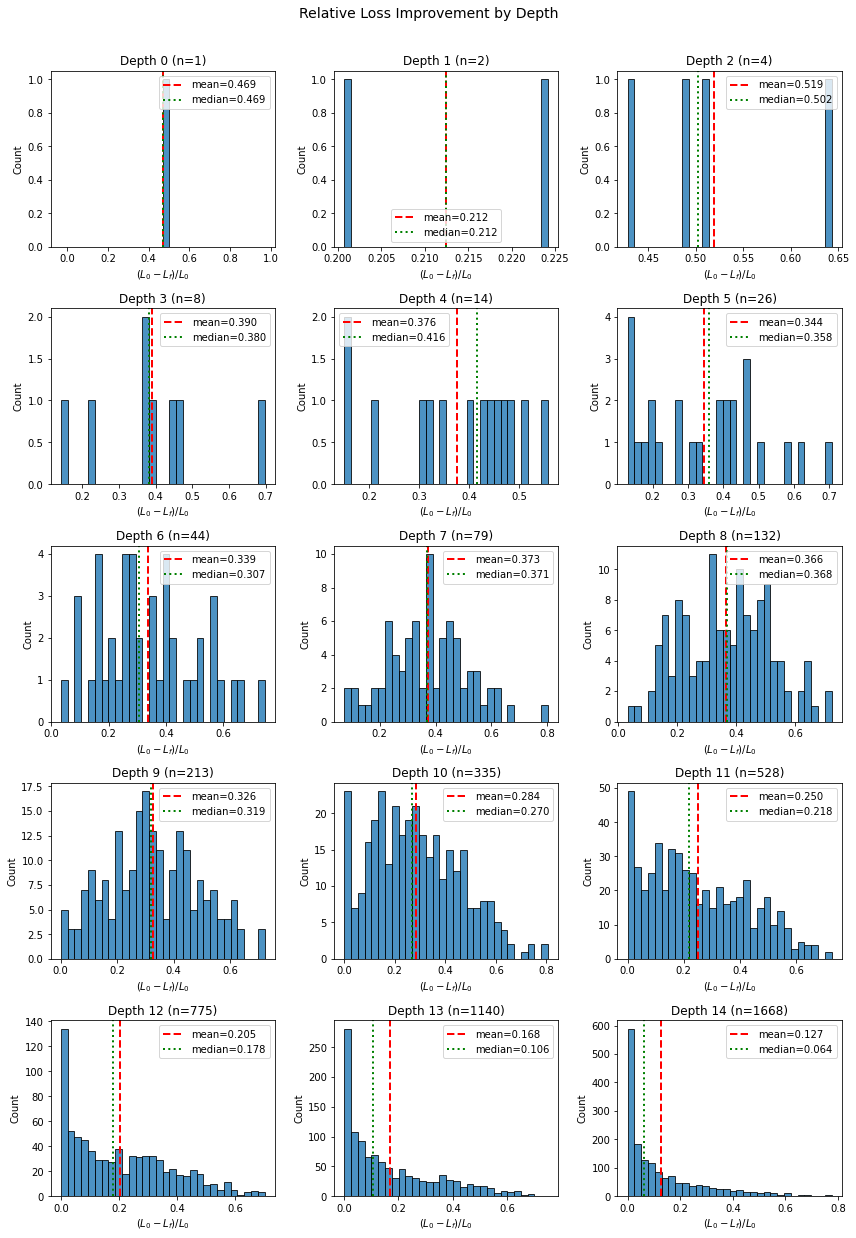

In [277]:
# print_split_fit_summary(tree)

# summary = relative_loss_decrease_summary_by_depth(tree)
# for depth, stats in summary.items():
#     print(
#         f"depth={depth}, n={stats['n_nodes']}, "
#         f"avg={stats['avg_rel_decrease']:.6f}, "
#         f"median={stats['median_rel_decrease']:.6f}, "
#         f"min={stats['min_rel_decrease']:.6f}, "
#         f"max={stats['max_rel_decrease']:.6f}"
#     )


plot_relative_loss_improvement_histograms_by_depth(tree)


0.009498155671349194
1.1788280789802836


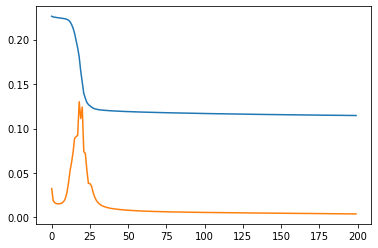

In [272]:
# /L/L/L/L/L/R/R
v = tree.get_node("root/L/R/R/L/R/L")
plt.plot(v.fit_result.loss_history)
plt.plot(v.fit_result.grad_norm_history)
# plt.plot(tree.root.right.right.right.right.right.right.right.right.right.fit_result))
print(v.fit_result.w_norm_penalty)
print(norm(v.w))

In [ ]:
from matplotlib.colors import ListedColormap


def plot_leaf_regions_with_contours_2d(tree, bounds, oracle, n_grid=300, n_contours=20,
                                       title="Leaf Regions with Oracle Contours"):
    bounds = np.asarray(bounds, dtype=float)
    if bounds.shape != (2, 2):
        raise ValueError("bounds must have shape (2, 2)")

    x1_min, x1_max = bounds[0]
    x2_min, x2_max = bounds[1]

    x1 = np.linspace(x1_min, x1_max, n_grid)
    x2 = np.linspace(x2_min, x2_max, n_grid)
    X1, X2 = np.meshgrid(x1, x2)
    Xg = np.column_stack([X1.ravel(), X2.ravel()])

    # Leaf assignment
    leaf_objs = [tree.leaf_for_point(x) for x in Xg]
    leaf_ids = [id(leaf) for leaf in leaf_objs]
    unique_leaf_ids = sorted(set(leaf_ids))
    leaf_to_label = {leaf_id: k for k, leaf_id in enumerate(unique_leaf_ids)}
    Z = np.array([leaf_to_label[leaf_id] for leaf_id in leaf_ids], dtype=int).reshape(n_grid, n_grid)

    n_leaves = len(unique_leaf_ids)

    # Adjacency graph for contrasting colors
    adjacency = {k: set() for k in range(n_leaves)}

    for i in range(n_grid - 1):
        for j in range(n_grid):
            a, b = Z[i, j], Z[i + 1, j]
            if a != b:
                adjacency[a].add(b)
                adjacency[b].add(a)

    for i in range(n_grid):
        for j in range(n_grid - 1):
            a, b = Z[i, j], Z[i, j + 1]
            if a != b:
                adjacency[a].add(b)
                adjacency[b].add(a)

    palette = [
        "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
        "#ffff33", "#a65628", "#f781bf", "#17becf", "#7f7f7f",
        "#1b9e77", "#d95f02", "#7570b3", "#66a61e", "#e6ab02",
        "#a6761d", "#666666"
    ]

    order = sorted(range(n_leaves), key=lambda k: len(adjacency[k]), reverse=True)
    color_idx = {}

    for node in order:
        used = {color_idx[nbr] for nbr in adjacency[node] if nbr in color_idx}
        for c in range(len(palette)):
            if c not in used:
                color_idx[node] = c
                break
        else:
            color_idx[node] = node % len(palette)

    Z_color = np.vectorize(lambda z: color_idx[z])(Z)
    cmap = ListedColormap(palette)

    # Oracle values and log contours
    # F = np.array([oracle(x) for x in Xg], dtype=float).reshape(n_grid, n_grid)
    # F_log = np.log10(np.maximum(np.abs(F), 1e-12))

    plt.figure(figsize=(6, 6))
    plt.pcolormesh(X1, X2, Z_color, shading="auto", cmap=cmap, alpha=1.0)

    # cs = plt.contour(X1, X2, F_log, levels=n_contours, colors="black", linewidths=1.0)
    # plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

    rect = np.array([
        [x1_min, x2_min],
        [x1_max, x2_min],
        [x1_max, x2_max],
        [x1_min, x2_max],
        [x1_min, x2_min],
    ])
    plt.plot(rect[:, 0], rect[:, 1], color="black", lw=2)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.gca().set_aspect("equal")
    plt.show()


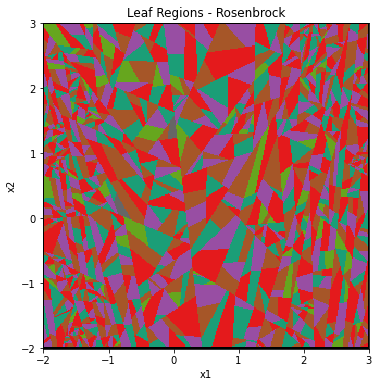

In [ ]:
plot_leaf_regions_with_contours_2d(
    tree=tree,
    bounds=bounds,
    oracle=oracle,
    n_grid=300,
    n_contours=20,
    title="Leaf Regions - Rosenbrock"
)


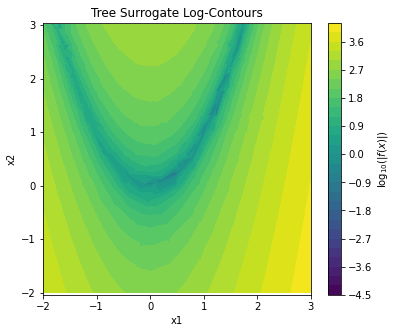

In [ ]:
plot_log_contours_2d(
    predict_fn=tree.predict_one,
    bounds=bounds,
    n_grid=250,
    title="Tree Surrogate Log-Contours"
)
